In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix

In [25]:
# 1. Load Data
train_path = r'C:\Users\Admin\Downloads\train.csv'
test_path = r'C:\Users\Admin\Downloads\test.csv'

train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

cols = ['S1', 'C1', 'S2', 'C2', 'S3', 'C3', 'S4', 'C4', 'S5', 'C5', 'CLASS']
train_df.columns = cols
test_df.columns = cols

X_train = train_df.drop('CLASS', axis=1)
y_train = train_df['CLASS']

X_test = test_df.drop('CLASS', axis=1)
y_test = test_df['CLASS']

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")


Train set: (25010, 10), Test set: (1000000, 10)


In [26]:
# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
print("Training Linear Regression model...")
lr_model.fit(X_train, y_train)
print("Training completed!")

Training Linear Regression model...
Training completed!


In [27]:
# Predict decimal values
y_pred_raw = lr_model.predict(X_test)

# Round to integers and clip to the valid label range (0 to 9)
y_pred_rounded = np.round(y_pred_raw)
y_pred_rounded = np.clip(y_pred_rounded, 0, 9)

# Print a sample to observe the difference
print("5 decimal predictions (Regression outputs):")
print(y_pred_raw[:5])
print("\n5 predictions after rounding to integer (Used for Accuracy):")
print(y_pred_rounded[:5])

5 decimal predictions (Regression outputs):
[0.6019253  0.62501413 0.59932299 0.58147301 0.63045342]

5 predictions after rounding to integer (Used for Accuracy):
[1. 1. 1. 1. 1.]


In [28]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred_raw)
accuracy = accuracy_score(y_test, y_pred_rounded)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Detailed classification report
print("Classification Report:")
# Add zero_division=0 to suppress warnings when the model fails to predict rare classes
print(classification_report(y_test, y_pred_rounded, zero_division=0))

Mean Squared Error (MSE): 0.5983
Accuracy: 42.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    501209
           1       0.42      1.00      0.59    422498
           2       0.00      0.00      0.00     47622
           3       0.00      0.00      0.00     21121
           4       0.00      0.00      0.00      3885
           5       0.00      0.00      0.00      1996
           6       0.00      0.00      0.00      1424
           7       0.00      0.00      0.00       230
           8       0.00      0.00      0.00        12
           9       0.00      0.00      0.00         3

    accuracy                           0.42   1000000
   macro avg       0.04      0.10      0.06   1000000
weighted avg       0.18      0.42      0.25   1000000



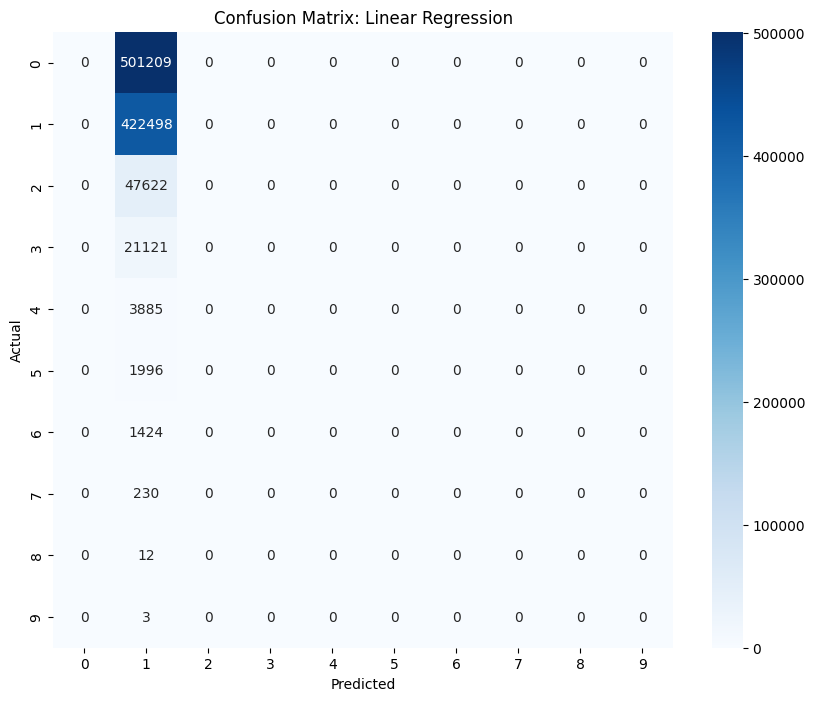

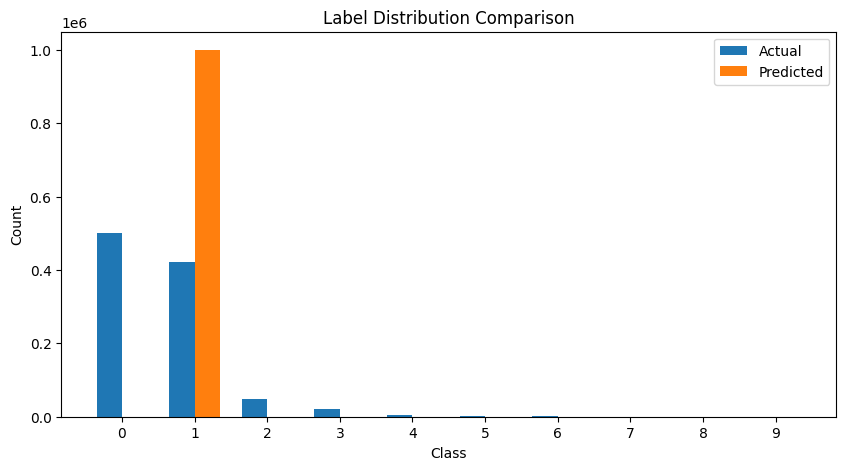

In [29]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_rounded, labels=range(10)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix: Linear Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Label Distribution Comparison Chart
plt.figure(figsize=(10, 5))
actual_counts = pd.Series(y_test).value_counts().reindex(range(10), fill_value=0).sort_index()
pred_counts = pd.Series(y_pred_rounded).value_counts().reindex(range(10), fill_value=0).sort_index()

width = 0.35
x = np.arange(10)

plt.bar(x - width/2, actual_counts, width, label='Actual')
plt.bar(x + width/2, pred_counts, width, label='Predicted')
plt.xticks(x, range(10))
plt.title('Label Distribution Comparison')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend()
plt.show()